# Assignment 3: Image Classification using CNN on CIFAR-10 Dataset

In [2]:
# Phase 1: Import Required Libraries

# PyTorch Core Library
import torch
# Neural Network Modules
import torch.nn as nn

# Optimization Algorithms
import torch.optim as optim

# Computer Vision Utilities
import torchvision
import torchvision.transforms as transforms

# Data Loading Utilities
from torch.utils.data import DataLoader

# Data Visualization
import matplotlib.pyplot as plt

# Numerical Operations
import numpy as np

In [3]:
# Phase 2: Load and Preprocess the CIFAR-10 Dataset

# Define image transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

# Load the training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root="../datasets/cifar10",
    train=True,
    download=True,
    transform=transform
)

# Load the testing dataset
test_dataset = torchvision.datasets.CIFAR10(
    root="../datasets/cifar10",
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100.0%


Training Images : 50000
Testing Images  : 10000
CIFAR-10 Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image Batch Shape : torch.Size([64, 3, 32, 32])
Label Batch Shape : torch.Size([64])


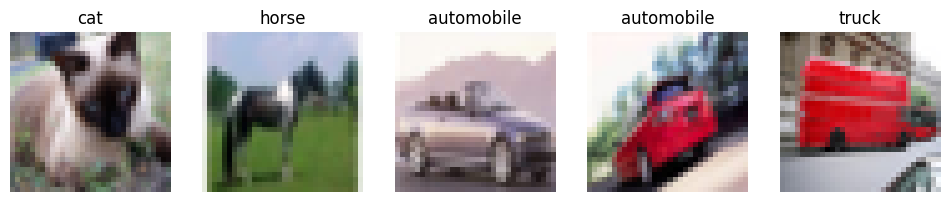

In [4]:
# Phase 3: Dataset Exploration

# Display the number of images in the training and testing datasets
print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

# Display the class names in the CIFAR-10 dataset
print("CIFAR-10 Classes:")
print(train_dataset.classes)

# Load one batch of training data
images, labels = next(iter(train_loader))
print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

# Display a few sample images from the training dataset
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image = images[i] / 2 + 0.5          # Reverse normalization
    image = image.numpy().transpose((1, 2, 0))

    axes[i].imshow(image)
    axes[i].set_title(train_dataset.classes[labels[i]])
    axes[i].axis("off")

plt.show()